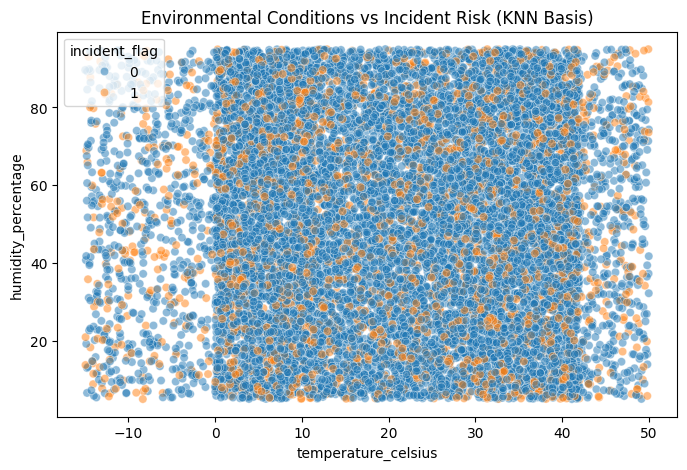

Optimal Parameters: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}

--- PERFORMANCE METRIC (KNN REGRESSION AUDIT) ---
MSE: 0.1427
RMSE: 0.3777
MAE: 0.2668
R2 Score: 0.0333
AUC: 0.6550

--- PREDICTED OUTPUT ---
   record_id  predicted_risk_score
0  DG_017501              0.000000
1  DG_017502              0.095238
2  DG_017503              0.047619
3  DG_017504              0.047619
4  DG_017505              0.142857


In [3]:
# ==========================================
# 1. DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
# Correct Regression Metrics
from sklearn.metrics import (roc_auc_score, mean_squared_error, mean_absolute_error,r2_score, log_loss, brier_score_loss)

train_df = pd.read_csv('dg_incident_train.csv')
val_df = pd.read_csv('dg_incident_validation.csv')
test_df = pd.read_csv('dg_incident_test.csv')

# ==========================================
# 2. DATA CLEANING
# ==========================================
def clean_dataset(df):
    return df.drop_duplicates().dropna()

train_df = clean_dataset(train_df)
val_df = clean_dataset(val_df)
test_df = clean_dataset(test_df)

# ==========================================
# 3. DATA PREPROCESSING
# ==========================================
def engineer_safety_features(df):
    df['climate_shock_risk'] = ((df['origin_destination'] == 'OSL-JED') & (df['temperature_celsius'] > 30)).astype(int)
    df['is_untrusted_shipper'] = (df['previous_incident_count'] > 5).astype(int)
    return df

train_df = engineer_safety_features(train_df)
val_df = engineer_safety_features(val_df)
test_df = engineer_safety_features(test_df)

cat_cols = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']
for col in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], val_df[col], test_df[col]]).astype(str)
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col].astype(str))
    val_df[col] = le.transform(val_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

drop_cols = ['record_id', 'timestamp', 'shipper_id', 'incident_flag']
X_train, y_train = train_df.drop(columns=drop_cols), train_df['incident_flag']
X_test, y_test = test_df.drop(columns=drop_cols), test_df['incident_flag']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. DATA VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 5))
sns.scatterplot(x='temperature_celsius', y='humidity_percentage', hue='incident_flag', data=train_df, alpha=0.5)
plt.title("Environmental Conditions vs Incident Risk (KNN Basis)")
plt.show()

# ==========================================
# 5. MODEL BUILT & 6. HYPERPARAMETER TUNING
# ==========================================
knn_model = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [5, 11, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 8. GRID SEARCH (Optimizing for Regression Error)
grid_search = GridSearchCV(knn_model, param_grid, scoring='neg_mean_squared_error', cv=3)
grid_search.fit(X_train_scaled, y_train)

# ==========================================
# 7. TESTING & 9. PERFORMANCE METRICS (REGRESSION)
# ==========================================
best_knn = grid_search.best_estimator_
y_probs = best_knn.predict_proba(X_test_scaled)[:, 1]

mse = mean_squared_error(y_test, y_probs)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_probs)
r2 = r2_score(y_test, y_probs)

print(f"Optimal Parameters: {grid_search.best_params_}")
print("\n--- PERFORMANCE METRIC (KNN REGRESSION AUDIT) ---")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"AUC: {roc_auc_score(y_test, y_probs):.4f}")


# ==========================================
# 10. OUTPUT / PREDICTED OUTPUT
# ==========================================
test_df['predicted_risk_score'] = y_probs
print("\n--- PREDICTED OUTPUT ---")
print(test_df[['record_id', 'predicted_risk_score']].head())